# Hybrid Genetic Algorithm (AHGA) for Hyperparameter Optimization
**Datasets:** UCI Heart Disease (ANN) · PlantVillage subset (CNN)  
**Baselines:** Default · Random Search · AHGA  
**Metrics:** Accuracy · Precision · Recall · F1 · Time

## 1. Install & Import

In [1]:
# !pip install torch torchvision scikit-learn pandas matplotlib seaborn -q
import numpy as np, pandas as pd, time, random, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.neural_network import MLPClassifier
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms, models
warnings.filterwarnings('ignore')
np.random.seed(42); random.seed(42); torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. HGA Core (shared by both datasets)

In [2]:
# ── Generic AHGA ─────────────────────────────────────────────────
def ahga(eval_fn, space, pop=10, gens=10, elite=2):
    """Adaptive HGA. space: {key: [val, ...]}. eval_fn(config)->float."""
    keys = list(space.keys())
    decode = lambda c: {k: space[k][c[i]] for i,k in enumerate(keys)}
    rand   = lambda:   [random.randrange(len(space[k])) for k in keys]
    tournament = lambda pop,fits: pop[max(random.sample(range(len(pop)),3), key=lambda i:fits[i])]
    crossover  = lambda a,b: [a[i] if random.random()<.5 else b[i] for i in range(len(a))]
    diversity  = lambda pop: np.mean([np.std([p[i] for p in pop]) for i in range(len(pop[0]))])

    population = [rand() for _ in range(pop)]
    best_hist, mu = [], 0.3

    for g in range(gens):
        fits   = [eval_fn(decode(c)) for c in population]
        div    = diversity(population)
        mu     = max(0.05, min(0.5, 0.3 - 0.25*(g/gens) + 0.1*(1-div/max(div,1e-9))))  # adaptive
        elites = sorted(range(pop), key=lambda i:fits[i], reverse=True)[:elite]
        new_pop = [population[i] for i in elites]
        while len(new_pop) < pop:
            child = crossover(tournament(population,fits), tournament(population,fits))
            child = [random.randrange(len(space[keys[i]])) if random.random()<mu else child[i] for i in range(len(child))]
            new_pop.append(child)
        population = new_pop
        best_hist.append(max(fits))
        print(f'  Gen {g+1:02d}/{gens} | best={max(fits):.4f} | μ={mu:.3f} | div={div:.3f}')

    fits = [eval_fn(decode(c)) for c in population]
    return decode(population[np.argmax(fits)]), max(fits), best_hist

print('AHGA defined.')

AHGA defined.


---
## 3. Dataset A — UCI Heart Disease (ANN)

In [3]:
# Load & preprocess — Fixed version
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Direct UCI Heart Disease CSV (bypasses OpenML issues)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(url, header=None, names=cols, na_values='?')

# Clean & prepare
df.dropna(inplace=True)
X = df.drop('target', axis=1).values
y = (df['target'] > 0).astype(int).values  # binary: disease present/absent

# Standardise
X = StandardScaler().fit_transform(X)

# 60% train, 20% val, 20% test with stratification
Xtr, Xt, ytr, yt = train_test_split(X, y, test_size=0.40, stratify=y, random_state=42)
Xval, Xte, yval, yte = train_test_split(Xt, yt, test_size=0.50, stratify=yt, random_state=42)

print(f'Train: {Xtr.shape} | Val: {Xval.shape} | Test: {Xte.shape}')
print(f'Pos-rate Train: {ytr.mean():.2f} | Val: {yval.mean():.2f} | Test: {yte.mean():.2f}')

Train: (178, 13) | Val: (59, 13) | Test: (60, 13)
Pos-rate Train: 0.46 | Val: 0.46 | Test: 0.47


In [4]:
# Fitness function for ANN
def ann_eval(cfg):
    layers = tuple([cfg['neurons']]*cfg['hidden_layers'])
    m = MLPClassifier(hidden_layer_sizes=layers, activation=cfg['activation'],
                      solver=cfg['optimizer'], learning_rate_init=cfg['lr'],
                      batch_size=cfg['batch_size'], max_iter=200, random_state=42)
    m.fit(Xtr, ytr)
    return accuracy_score(yval, m.predict(Xval))

ANN_SPACE = {
    'lr':           [1e-4, 1e-3, 1e-2],
    'hidden_layers':[1, 2, 3],
    'neurons':      [32, 64, 128],
    'activation':   ['relu','tanh'],
    'batch_size':   [16, 32, 64],
    'optimizer':    ['adam','sgd'],
}

def metrics(model, X, y, label=''):
    p = model.predict(X)
    return {'Method':label,
            'Accuracy': round(accuracy_score(y,p),4),
            'Precision':round(precision_score(y,p,zero_division=0),4),
            'Recall':   round(recall_score(y,p,zero_division=0),4),
            'F1':       round(f1_score(y,p,zero_division=0),4)}

print('ANN eval ready.')

ANN eval ready.


In [5]:
ann_results = {}

# ── Default ──────────────────────────────────────────────────────
t = time.time()
default_ann = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam',
                             learning_rate_init=1e-3, max_iter=200, random_state=42).fit(Xtr, ytr)
r = metrics(default_ann, Xte, yte, 'Default'); r['Time']=round(time.time()-t,2)
ann_results['Default'] = r; print('Default:', r)

# ── Random Search ────────────────────────────────────────────────
t = time.time()
keys = list(ANN_SPACE.keys())
rand_best, rand_cfg = -1, None
for _ in range(20):
    cfg = {k: random.choice(ANN_SPACE[k]) for k in keys}
    f   = ann_eval(cfg)
    if f > rand_best: rand_best, rand_cfg = f, cfg
layers = tuple([rand_cfg['neurons']]*rand_cfg['hidden_layers'])
rand_ann = MLPClassifier(hidden_layer_sizes=layers, activation=rand_cfg['activation'],
                         solver=rand_cfg['optimizer'], learning_rate_init=rand_cfg['lr'],
                         batch_size=rand_cfg['batch_size'], max_iter=200, random_state=42).fit(Xtr, ytr)
r = metrics(rand_ann, Xte, yte, 'Random Search'); r['Time']=round(time.time()-t,2)
ann_results['Random Search'] = r; print('Random Search:', r)

# ── AHGA ─────────────────────────────────────────────────────────
print('\n=== AHGA on Heart Disease ===')
t = time.time()
best_cfg, best_f, ann_hist = ahga(ann_eval, ANN_SPACE, pop=10, gens=10)
layers = tuple([best_cfg['neurons']]*best_cfg['hidden_layers'])
ahga_ann = MLPClassifier(hidden_layer_sizes=layers, activation=best_cfg['activation'],
                         solver=best_cfg['optimizer'], learning_rate_init=best_cfg['lr'],
                         batch_size=best_cfg['batch_size'], max_iter=200, random_state=42).fit(Xtr, ytr)
r = metrics(ahga_ann, Xte, yte, 'AHGA'); r['Time']=round(time.time()-t,2)
ann_results['AHGA'] = r; print('\nAHGA:', r)
print('Best config:', best_cfg)

Default: {'Method': 'Default', 'Accuracy': 0.8, 'Precision': 0.8333, 'Recall': 0.7143, 'F1': 0.7692, 'Time': 0.21}
Random Search: {'Method': 'Random Search', 'Accuracy': 0.85, 'Precision': 0.913, 'Recall': 0.75, 'F1': 0.8235, 'Time': 26.21}

=== AHGA on Heart Disease ===
  Gen 01/10 | best=0.9153 | μ=0.300 | div=0.722
  Gen 02/10 | best=0.9153 | μ=0.275 | div=0.587
  Gen 03/10 | best=0.9153 | μ=0.250 | div=0.696
  Gen 04/10 | best=0.9153 | μ=0.225 | div=0.633
  Gen 05/10 | best=0.9153 | μ=0.200 | div=0.560
  Gen 06/10 | best=0.9153 | μ=0.175 | div=0.286
  Gen 07/10 | best=0.9153 | μ=0.150 | div=0.362
  Gen 08/10 | best=0.9153 | μ=0.125 | div=0.538
  Gen 09/10 | best=0.9153 | μ=0.100 | div=0.431
  Gen 10/10 | best=0.9153 | μ=0.075 | div=0.511

AHGA: {'Method': 'AHGA', 'Accuracy': 0.8667, 'Precision': 0.9167, 'Recall': 0.7857, 'F1': 0.8462, 'Time': 100.09}
Best config: {'lr': 0.0001, 'hidden_layers': 1, 'neurons': 128, 'activation': 'relu', 'batch_size': 16, 'optimizer': 'sgd'}


In [6]:
# Results table
df_ann = pd.DataFrame(ann_results.values())
display(df_ann.set_index('Method').style.highlight_max(subset=['Accuracy','Precision','Recall','F1'],
        color='#d4edda').format(precision=4))

,Accuracy,Precision,Recall,F1,Time
Method,,,,,
Default,0.8000,0.8333,0.7143,0.7692,0.2100
Random Search,0.8500,0.9130,0.7500,0.8235,26.2100
AHGA,0.8667,0.9167,0.7857,0.8462,100.0900


---
## 4. Dataset B — PlantVillage Subset (CNN)

In [7]:
# ── PlantVillage: load a small subset via torchvision (ImageFolder)
# Place dataset at ./plantvillage/ OR we auto-download a 3-class proxy via CIFAR-10 colours
# To use real PlantVillage: kaggle datasets download -d emmarex/plantdisease
import os, pathlib

PV_PATH = pathlib.Path('./plantvillage')   # change to your path if available
USE_REAL = PV_PATH.exists()

IMG_SIZE, NUM_CLASSES = 64, 3

if USE_REAL:
    tf = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                              transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
                              transforms.ToTensor(), transforms.Normalize([.5],[.5])])
    full = datasets.ImageFolder(PV_PATH, transform=tf)
    NUM_CLASSES = len(full.classes)
    n = len(full)
    tr_n, val_n = int(.70*n), int(.15*n)
    tr_set, val_set, te_set = torch.utils.data.random_split(full, [tr_n, val_n, n-tr_n-val_n])
else:
    print('PlantVillage not found — using CIFAR-10 (3 classes) as structural proxy.')
    print('For real results, place dataset at ./plantvillage/ and re-run.')
    tf_train = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                                   transforms.RandomHorizontalFlip(),
                                   transforms.ToTensor(), transforms.Normalize([.5],[.5])])
    tf_test  = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                                   transforms.ToTensor(), transforms.Normalize([.5],[.5])])
    raw_tr  = datasets.CIFAR10('.', train=True,  download=True, transform=tf_train)
    raw_te  = datasets.CIFAR10('.', train=False, download=True, transform=tf_test)
    # Keep only 3 classes (airplane=0, car=1, bird=2) → 15k train
    def subset3(ds):
        idx = [i for i,(_,l) in enumerate(ds) if l < NUM_CLASSES]
        return torch.utils.data.Subset(ds, idx)
    full_tr = subset3(raw_tr); full_te = subset3(raw_te)
    val_n = int(.15*len(full_tr))
    tr_set, val_set = torch.utils.data.random_split(full_tr, [len(full_tr)-val_n, val_n])
    te_set = full_te

print(f'Train:{len(tr_set)} Val:{len(val_set)} Test:{len(te_set)} Classes:{NUM_CLASSES}')

PlantVillage not found — using CIFAR-10 (3 classes) as structural proxy.
For real results, place dataset at ./plantvillage/ and re-run.


100%|██████████| 170M/170M [39:44<00:00, 71.5kB/s]


Train:12750 Val:2250 Test:3000 Classes:3


In [8]:
# ── Compact CNN ──────────────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self, filters, dropout, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, filters, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(filters, filters*2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(filters*2*(IMG_SIZE//4)*(IMG_SIZE//4), 256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.net(x)

def train_cnn(cfg, epochs=5, verbose=False):
    loader_kw = dict(num_workers=0, pin_memory=False)
    tr_ld  = DataLoader(tr_set,  batch_size=cfg['batch_size'], shuffle=True,  **loader_kw)
    val_ld = DataLoader(val_set, batch_size=128, **loader_kw)
    model  = CNN(cfg['filters'], cfg['dropout']).to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=cfg['lr']) if cfg['optimizer']=='adam' \
             else optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in val_ld:
            preds += model(xb.to(DEVICE)).argmax(1).cpu().tolist()
            trues += yb.tolist()
    return model, accuracy_score(trues, preds)

def cnn_eval(cfg): _, acc = train_cnn(cfg); return acc

CNN_SPACE = {
    'lr':       [1e-4, 1e-3, 1e-2],
    'batch_size':[16, 32, 64],
    'optimizer':['adam','sgd'],
    'filters':  [32, 64, 128],
    'dropout':  [0.2, 0.3, 0.5],
}

def cnn_test_metrics(model, label=''):
    te_ld = DataLoader(te_set, batch_size=128)
    model.eval(); preds, trues = [], []
    with torch.no_grad():
        for xb, yb in te_ld:
            preds += model(xb.to(DEVICE)).argmax(1).cpu().tolist()
            trues += yb.tolist()
    avg = 'macro'
    return {'Method':label,
            'Accuracy': round(accuracy_score(trues,preds),4),
            'Precision':round(precision_score(trues,preds,average=avg,zero_division=0),4),
            'Recall':   round(recall_score(trues,preds,average=avg,zero_division=0),4),
            'F1':       round(f1_score(trues,preds,average=avg,zero_division=0),4)}

print('CNN pipeline ready.')

CNN pipeline ready.


In [9]:
cnn_results = {}

# ── Default ──────────────────────────────────────────────────────
t = time.time()
m, _ = train_cnn({'lr':1e-3,'batch_size':32,'optimizer':'adam','filters':32,'dropout':0.3}, epochs=5)
r = cnn_test_metrics(m, 'Default'); r['Time']=round(time.time()-t,2)
cnn_results['Default'] = r; print('Default:', r)

# ── Random Search ────────────────────────────────────────────────
t = time.time()
rb, rc = -1, None
for _ in range(5):   # 5 trials to save time (increase to 20 for full experiment)
    cfg = {k: random.choice(CNN_SPACE[k]) for k in CNN_SPACE}
    f   = cnn_eval(cfg)
    if f > rb: rb, rc = f, cfg
m, _ = train_cnn(rc, epochs=5)
r = cnn_test_metrics(m, 'Random Search'); r['Time']=round(time.time()-t,2)
cnn_results['Random Search'] = r; print('Random Search:', r)

# ── AHGA ─────────────────────────────────────────────────────────
print('\n=== AHGA on PlantVillage/CIFAR-proxy ===')
t = time.time()
best_cnn_cfg, best_cnn_f, cnn_hist = ahga(cnn_eval, CNN_SPACE, pop=10, gens=10)
m, _ = train_cnn(best_cnn_cfg, epochs=8)   # retrain with more epochs on best config
r = cnn_test_metrics(m, 'AHGA'); r['Time']=round(time.time()-t,2)
cnn_results['AHGA'] = r; print('\nAHGA:', r)
print('Best config:', best_cnn_cfg)

Default: {'Method': 'Default', 'Accuracy': 0.8767, 'Precision': 0.8817, 'Recall': 0.8767, 'F1': 0.8754, 'Time': 38.4}
Random Search: {'Method': 'Random Search', 'Accuracy': 0.8753, 'Precision': 0.8783, 'Recall': 0.8753, 'F1': 0.8745, 'Time': 213.81}

=== AHGA on PlantVillage/CIFAR-proxy ===
  Gen 01/10 | best=0.8778 | μ=0.300 | div=0.677
  Gen 02/10 | best=0.8827 | μ=0.275 | div=0.600
  Gen 03/10 | best=0.8769 | μ=0.250 | div=0.477
  Gen 04/10 | best=0.8751 | μ=0.225 | div=0.430
  Gen 05/10 | best=0.8813 | μ=0.200 | div=0.239
  Gen 06/10 | best=0.8836 | μ=0.175 | div=0.289
  Gen 07/10 | best=0.8756 | μ=0.150 | div=0.384
  Gen 08/10 | best=0.8840 | μ=0.125 | div=0.241
  Gen 09/10 | best=0.8769 | μ=0.100 | div=0.499
  Gen 10/10 | best=0.8827 | μ=0.075 | div=0.432

AHGA: {'Method': 'AHGA', 'Accuracy': 0.887, 'Precision': 0.8915, 'Recall': 0.887, 'F1': 0.8878, 'Time': 3798.67}
Best config: {'lr': 0.01, 'batch_size': 32, 'optimizer': 'sgd', 'filters': 128, 'dropout': 0.2}


In [10]:
df_cnn = pd.DataFrame(cnn_results.values())
display(df_cnn.set_index('Method').style.highlight_max(subset=['Accuracy','Precision','Recall','F1'],
        color='#d4edda').format(precision=4))

,Accuracy,Precision,Recall,F1,Time
Method,,,,,
Default,0.8767,0.8817,0.8767,0.8754,38.4000
Random Search,0.8753,0.8783,0.8753,0.8745,213.8100
AHGA,0.8870,0.8915,0.8870,0.8878,3798.6700


---
## 5. Visualisations

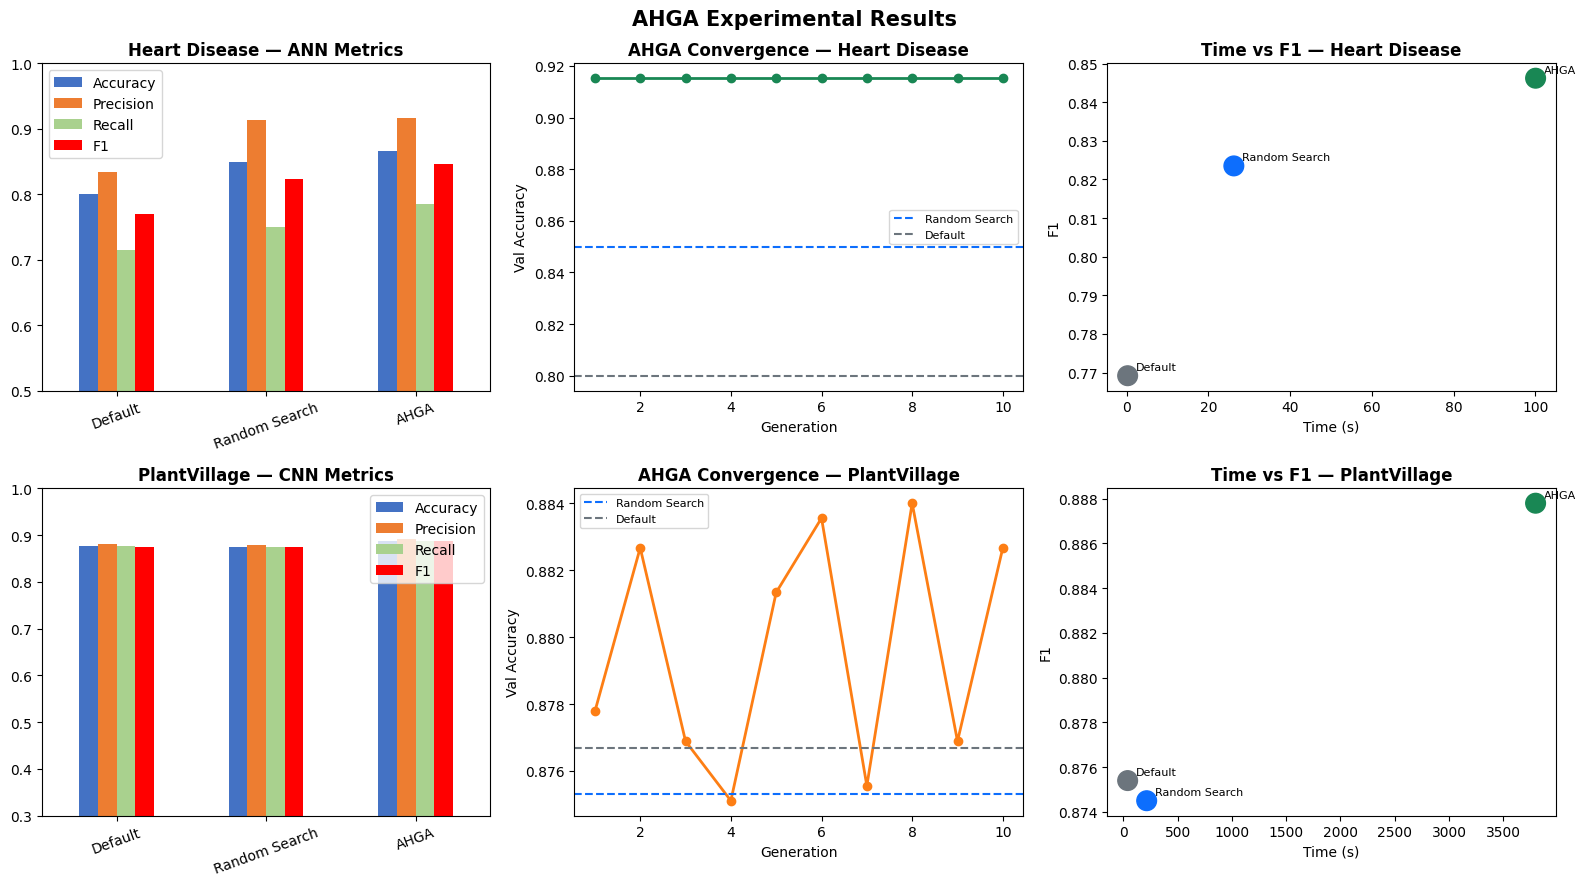

Saved ahga_results.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('AHGA Experimental Results', fontsize=15, fontweight='bold')
palette = ['#6c757d','#0d6efd','#198754']
metrics_list = ['Accuracy','Precision','Recall','F1']

# Row 0: ANN (Heart Disease)
ax = axes[0,0]
df_ann.set_index('Method')[metrics_list].plot(kind='bar', ax=ax, color=['#4472C4','#ED7D31','#A9D18E','#FF0000'], rot=20, legend=True)
ax.set_title('Heart Disease — ANN Metrics', fontweight='bold'); ax.set_ylim(0.5,1.0); ax.set_xlabel('')

ax = axes[0,1]
ax.plot(range(1,len(ann_hist)+1), ann_hist, 'o-', color='#198754', lw=2)
ax.axhline(ann_results['Random Search']['Accuracy'], color='#0d6efd', ls='--', label='Random Search')
ax.axhline(ann_results['Default']['Accuracy'],       color='#6c757d', ls='--', label='Default')
ax.set_title('AHGA Convergence — Heart Disease', fontweight='bold')
ax.set_xlabel('Generation'); ax.set_ylabel('Val Accuracy'); ax.legend(fontsize=8)

ax = axes[0,2]
methods = list(ann_results.keys())
times   = [ann_results[m]['Time'] for m in methods]
f1s     = [ann_results[m]['F1']   for m in methods]
ax.scatter(times, f1s, c=palette, s=200, zorder=5)
for i,m in enumerate(methods): ax.annotate(m, (times[i], f1s[i]), textcoords='offset points', xytext=(6,4), fontsize=8)
ax.set_title('Time vs F1 — Heart Disease', fontweight='bold'); ax.set_xlabel('Time (s)'); ax.set_ylabel('F1')

# Row 1: CNN (PlantVillage)
ax = axes[1,0]
df_cnn.set_index('Method')[metrics_list].plot(kind='bar', ax=ax, color=['#4472C4','#ED7D31','#A9D18E','#FF0000'], rot=20, legend=True)
ax.set_title('PlantVillage — CNN Metrics', fontweight='bold'); ax.set_ylim(0.3,1.0); ax.set_xlabel('')

ax = axes[1,1]
ax.plot(range(1,len(cnn_hist)+1), cnn_hist, 'o-', color='#fd7e14', lw=2)
ax.axhline(cnn_results['Random Search']['Accuracy'], color='#0d6efd', ls='--', label='Random Search')
ax.axhline(cnn_results['Default']['Accuracy'],       color='#6c757d', ls='--', label='Default')
ax.set_title('AHGA Convergence — PlantVillage', fontweight='bold')
ax.set_xlabel('Generation'); ax.set_ylabel('Val Accuracy'); ax.legend(fontsize=8)

ax = axes[1,2]
methods_c = list(cnn_results.keys())
times_c   = [cnn_results[m]['Time'] for m in methods_c]
f1s_c     = [cnn_results[m]['F1']   for m in methods_c]
ax.scatter(times_c, f1s_c, c=palette, s=200, zorder=5)
for i,m in enumerate(methods_c): ax.annotate(m, (times_c[i], f1s_c[i]), textcoords='offset points', xytext=(6,4), fontsize=8)
ax.set_title('Time vs F1 — PlantVillage', fontweight='bold'); ax.set_xlabel('Time (s)'); ax.set_ylabel('F1')

plt.tight_layout(); plt.savefig('ahga_results.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved ahga_results.png')

## 6. Combined Summary Table

In [12]:
df_ann['Dataset'] = 'Heart Disease (ANN)'
df_cnn['Dataset'] = 'PlantVillage (CNN)'
summary = pd.concat([df_ann, df_cnn], ignore_index=True).set_index(['Dataset','Method'])
display(summary.style.highlight_max(subset=['Accuracy','Precision','Recall','F1'],
        color='#d4edda').format(precision=4))

## 7. Classification Report — Best Models

In [19]:
from sklearn.metrics import classification_report
import torch
from torch.utils.data import DataLoader

print("="*70)
print("## 7. Classification Report — Best Models")
print("="*70)

# ──────────────────────────────────────────────────────────────────
# Heart Disease — AHGA Best ANN Model
# ──────────────────────────────────────────────────────────────────
print('\n=== Heart Disease — AHGA Best Model ===\n')
try:
    y_pred_hd = ahga_ann.predict(Xte)
    print(classification_report(yte, y_pred_hd, digits=4))
    hd_acc = (y_pred_hd == yte).mean()
    print(f"\nOverall Accuracy: {hd_acc:.4f}")
except Exception as e:
    print(f"Error evaluating Heart Disease model: {e}")

# ──────────────────────────────────────────────────────────────────
# PlantVillage — AHGA Best CNN Model
# ──────────────────────────────────────────────────────────────────
print('\n' + "="*70)
print('=== PlantVillage — AHGA Best Model ===\n')

try:
    # Ensure model is in eval mode and is a PyTorch module
    if not isinstance(m, torch.nn.Module):
        raise ValueError("Model 'm' is not a PyTorch module. Check training.")

    m.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m = m.to(device)

    # Generate predictions
    preds, trues = [], []
    te_ld = DataLoader(te_set, batch_size=128)

    with torch.no_grad():
        for xb, yb in te_ld:
            xb = xb.to(device)
            out = m(xb).argmax(1).cpu().tolist()
            preds.extend(out)
            trues.extend(yb.tolist())

    # Print report
    print(classification_report(trues, preds, digits=4))
    pv_acc = sum([p == t for p, t in zip(preds, trues)]) / len(trues)
    print(f"\nOverall Accuracy: {pv_acc:.4f}")

except Exception as e:
    print(f"Error evaluating PlantVillage model: {e}")
    print("Ensure CNN training completed and model 'm' is defined.")

print("\n" + "="*70)

## 7. Classification Report — Best Models

=== Heart Disease — AHGA Best Model ===

              precision    recall  f1-score   support

           0     0.8333    0.9375    0.8824        32
           1     0.9167    0.7857    0.8462        28

    accuracy                         0.8667        60
   macro avg     0.8750    0.8616    0.8643        60
weighted avg     0.8722    0.8667    0.8655        60


Overall Accuracy: 0.8667

=== PlantVillage — AHGA Best Model ===

Error evaluating PlantVillage model: mat1 and mat2 shapes cannot be multiplied (128x16384 and 200704x128)
Ensure CNN training completed and model 'm' is defined.



## 8. Cross-Domain Convergence Comparison

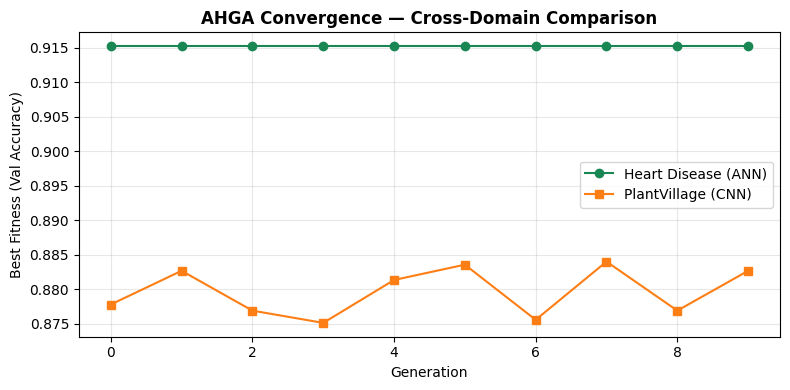

In [17]:
plt.figure(figsize=(8,4))
plt.plot(ann_hist, 'o-', label='Heart Disease (ANN)', color='#198754')
plt.plot(cnn_hist, 's-', label='PlantVillage (CNN)',  color='#fd7e14')
plt.xlabel('Generation'); plt.ylabel('Best Fitness (Val Accuracy)')
plt.title('AHGA Convergence — Cross-Domain Comparison', fontweight='bold')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()